2026-07-31 17:35:37,712 [INFO] Kích thước tập Train: (1196, 10), Tập Test: (300, 10)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Đã nạp thành công dữ liệu MBB (1496 dòng) và Model XGBoost!
📊 Số ngày AI nắm giữ vị thế MBB (logic Gồng Lãi): 58 / 300 ngày (19.3%)


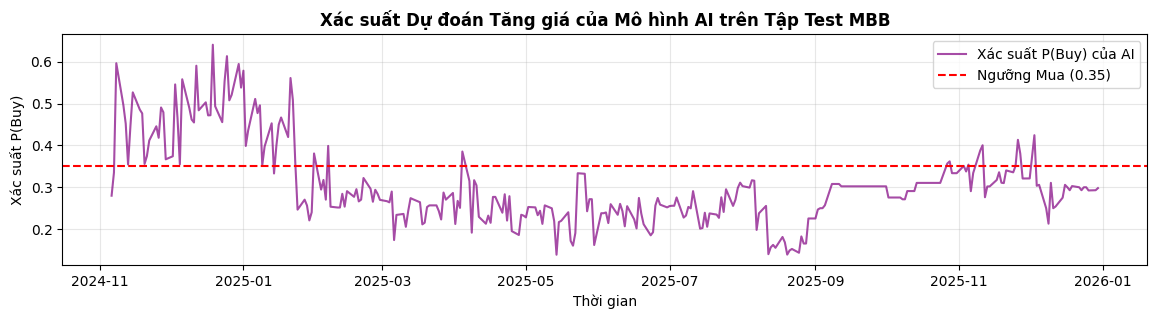

2026-07-31 17:35:38,049 [INFO] Bắt đầu mô phỏng Backtest...



BÁO CÁO HIỆU SUẤT GIAO DỊCH DỰ BÁO MBB (BACKTEST RESULTS)
- Total Return (AI Strategy)    : 4.51%
- Total Return (Buy & Hold)     : 48.17%
- Sharpe Ratio (AI)             : 0.54
- Max Drawdown (AI)             : 5.80%
- Max Drawdown (Buy & Hold)     : 16.73%
- Win Rate                      : 41.38%
- Total Trades Executed         : 4


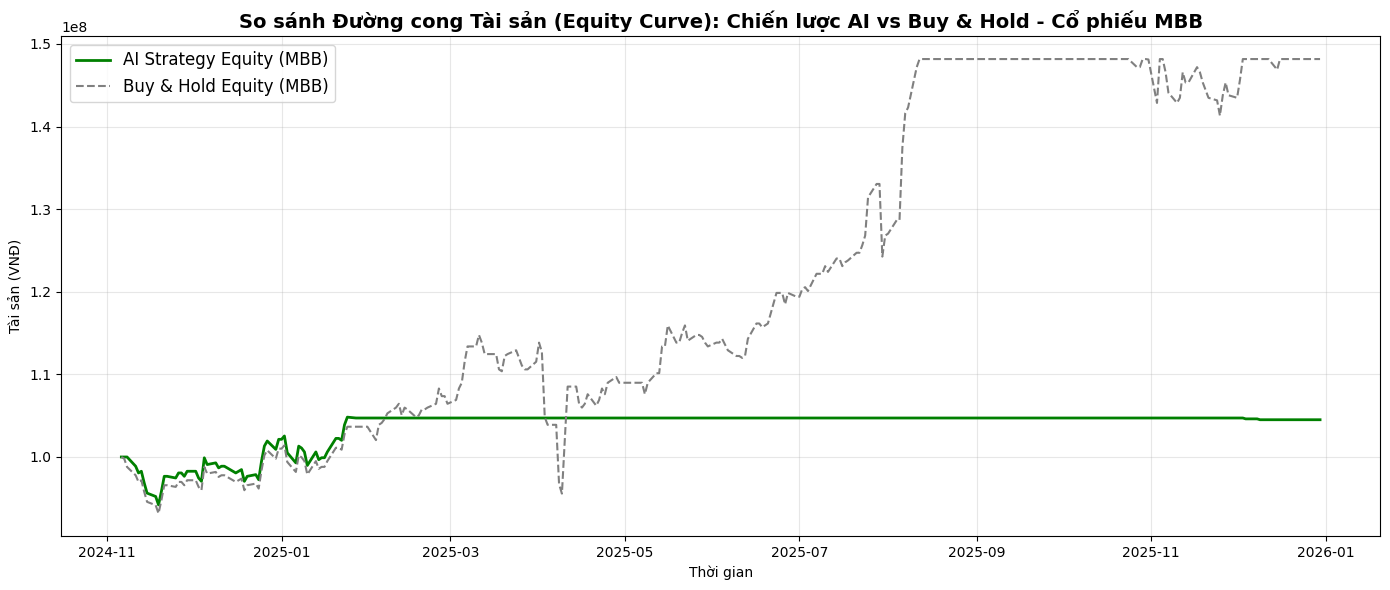

In [ ]:
# Cell 1: Import 
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.model_trainer import ModelTrainer
from utils.backtester import VectorizedBacktester

# 1. Nạp dữ liệu MBB
df_ml = pd.read_parquet("../data/processed/MBB_ml_ready.parquet")

# 2. Nạp Model XGBoost
model = joblib.load("../data/processed/xgboost_model.pkl")
expected_features = list(model.feature_names_in_)

# 3. TỰ ĐỘNG BỔ SUNG CỘT THIẾU (Ví dụ: SMA_50)
missing_cols = [col for col in expected_features if col not in df_ml.columns]

if missing_cols:
    print(f"⚠️ Phát hiện thiếu {len(missing_cols)} cột: {missing_cols}")
    print("🔄 Đang tự động bù đắp dữ liệu...")
    
    for col in missing_cols:
        if col == 'SMA_50' and 'Close' in df_ml.columns:
            df_ml['SMA_50'] = df_ml['Close'].rolling(window=50, min_periods=1).mean()
        else:
            df_ml[col] = 0.0  # Gán giá trị mặc định cho cột thiếu khác (nếu có)
            
    print("✅ Đã bổ sung đầy đủ các cột đặc trưng!")

print(f"✅ Đã nạp thành công dữ liệu MBB ({len(df_ml)} dòng) và Model XGBoost!")


# Cell 2: Tự động Đặt Ngưỡng theo Bách Phân Vị (Dynamic Quantile) & Gồng Lãi
trainer = ModelTrainer(df_ml, target_col='Target')
X_train, X_test, y_train, y_test = trainer.time_series_split(test_size=0.2)

X_test_selected = X_test[expected_features]
test_df = df_ml.loc[X_test.index].copy()

# 1. Dự đoán chuỗi xác suất P(Buy)
y_probs = pd.Series(model.predict_proba(X_test_selected)[:, 1], index=test_df.index)

# In thống kê thực tế để soi xác suất AI
print("=== THỐNG KÊ XÁC SUẤT AI DỰ ĐOÁN NĂM 2025 ===")
if '2025' in y_probs.index.year.astype(str):
    p_2025 = y_probs.loc['2025']
    print(f"- Xác suất Cao nhất: {p_2025.max():.4f}")
    print(f"- Xác suất Thấp nhất: {p_2025.min():.4f}")
    print(f"- Xác suất Trung bình: {p_2025.mean():.4f}")
print("="*45)

# 2. TỰ ĐỘNG ĐẶT NGƯỠNG ĐỘNG (DYNAMIC THRESHOLD)
# BUY_ENTRY: Lấy mốc Bách phân vị 65% (Nghĩa là Top 35% ngày AI tự tin nhất)
BUY_ENTRY = y_probs.quantile(0.65)  

# SELL_EXIT: Lấy mốc Bách phân vị 30% (Khi độ tự tin tụt xuống Top 30% thấp nhất thì BÁN)
SELL_EXIT = y_probs.quantile(0.30)  

print(f"🎯 Ngưỡng MUA tự động (Top 35% tự tin nhất): {BUY_ENTRY:.4f}")
print(f"🛑 Ngưỡng BÁN tự động (Vùng 30% rủi ro nhất): {SELL_EXIT:.4f}")

# 3. Thuật toán Gồng Lãi (State Machine)
signals = []
current_pos = 0

for prob in y_probs:
    if current_pos == 0:
        if prob >= BUY_ENTRY:
            current_pos = 1  # Kích hoạt MUA
    else:  # Đang giữ cổ phiếu
        if prob < SELL_EXIT:
            current_pos = 0  # Kích hoạt BÁN
            
    signals.append(current_pos)

predictions = pd.Series(signals, index=test_df.index)

print(f"\n✅ Số ngày AI nắm giữ cổ phiếu MBB: {predictions.sum()} / {len(predictions)} ngày ({predictions.sum()/len(predictions)*100:.1f}%)")
# Cell 2.1: Trực quan hóa Xác suất AI dự đoán qua thời gian
plt.figure(figsize=(14, 3))
plt.plot(y_probs.index, y_probs.values, color='purple', alpha=0.7, label='Xác suất P(Buy) của AI')
plt.axhline(BUY_THRESHOLD, color='red', linestyle='--', label=f'Ngưỡng Mua ({BUY_THRESHOLD})')
plt.title("Xác suất Dự đoán Tăng giá của Mô hình AI trên Tập Test MBB", fontsize=12, fontweight="bold")
plt.xlabel("Thời gian")
plt.ylabel("Xác suất P(Buy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cell 3: Chạy Backtest Mô phỏng Giao dịch MBB
# Thiết lập vốn 100 triệu VNĐ & phí giao dịch 0.1% (mức trung bình sàn VPS/TCBS)
INITIAL_CAPITAL = 100000000.0  
FEE_RATE = 0.001               

backtester = VectorizedBacktester(test_df, initial_capital=INITIAL_CAPITAL, fee_rate=FEE_RATE)
df_results = backtester.run_backtest(predictions)
metrics = backtester.evaluate_performance()

# In Báo cáo Hiệu suất Tài chính MBB
print("\n" + "="*60)
print("BÁO CÁO HIỆU SUẤT GIAO DỊCH DỰ BÁO MBB (BACKTEST RESULTS)")
print("="*60)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"- {k:<30}: {v:,.2f}")
    else:
        print(f"- {k:<30}: {v}")
print("="*60)

# Cell 4: Trực quan hóa Đường cong Tài sản (Equity Curve) MBB
plt.figure(figsize=(14, 6))
plt.plot(df_results.index, df_results['Equity_AI'], label='AI Strategy Equity (MBB)', color='green', linewidth=2)
plt.plot(df_results.index, df_results['Equity_BuyHold'], label='Buy & Hold Equity (MBB)', color='gray', linestyle='--', linewidth=1.5)

plt.title("So sánh Đường cong Tài sản (Equity Curve): Chiến lược AI vs Buy & Hold - Cổ phiếu MBB", fontsize=14, fontweight="bold")
plt.xlabel("Thời gian")
plt.ylabel("Tài sản (VNĐ)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 5: Trực quan hóa Mức sụt giảm Tài sản (Drawdown Chart) MBB
if 'Drawdown_AI' in df_results.columns:
    plt.figure(figsize=(14, 4))
    plt.fill_between(df_results.index, df_results['Drawdown_AI'] * 100, 0, color='red', alpha=0.3, label='AI Strategy Drawdown (%)')
    plt.title("Biểu đồ Mức sụt giảm Tài sản Tối đa (Maximum Drawdown) - MBB", fontsize=12, fontweight="bold")
    plt.xlabel("Thời gian")
    plt.ylabel("Sụt giảm (%)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()